E_iso,gamma: 9.999999558137433e+50
E_peak: 669616.0054853215 eV
Normalized L0: 2.9990793771929073e+52


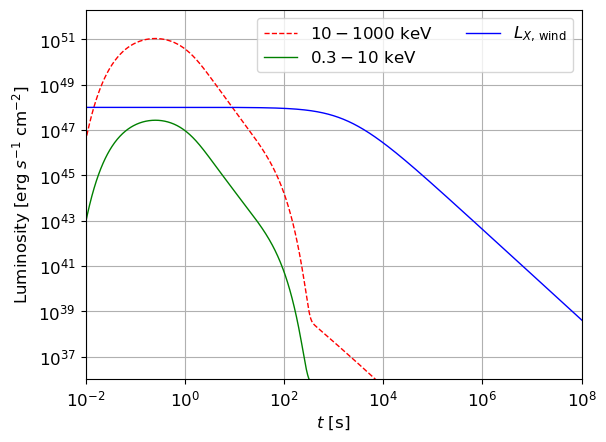

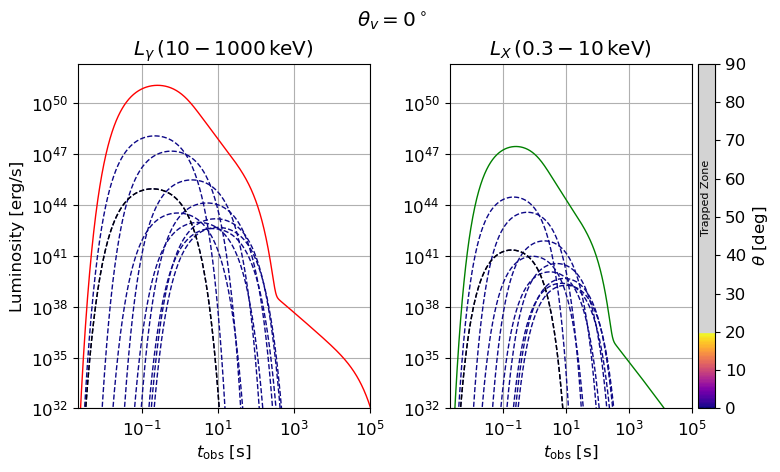

In [32]:
# ============================================================================= #
#                  ____  ____   __   _  _  ____  ____  _  _                     #
#                 (  _ \(  _ \ /  \ ( \/ )(  _ \(_  _)( \/ )                    #
#                  ) __/ )   /(  O )/ \/ \ ) __/  )(   )  (                     #
#                 (__)  (__\_) \__/ \_)(_/(__)   (__) (_/\_)                    #
#                                                                               #
# ============================================================================= #
#   PromptX - Prompt X-ray emission modeling of relativistic outflows           #
#   Version 1.0                                                                 #
#   Author: Connery Chen, Yihan Wang, and Bing Zhang                            #
#   License: MIT                                                                #
# ============================================================================= # 

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap
import os

from scripts.jet2 import Jet
from scripts.wind import Wind

plt.rcParams.update({'font.size': 12})

def plot_lc(jet, wind, path='./out/', model_id=0):
    """
    Plot the light curves of the jet and wind components.

    Args:
        jet (Jet): Jet object containing the emission data.
        wind (Wind): Wind object containing the emission data.
        theta_los (float): Line-of-sight angle in radians.
        phi_los (float): Azimuthal viewing angle in radians.
        path (str): Directory path to save the figure.
        model_id (int): Model identifier (controls whether wind is plotted).
    """

    fig_lc, ax_lc = plt.subplots()

    # Plot jet light curves
    ax_lc.plot(jet.t, jet.L_gamma_tot, lw=1, c='r', ls='--', label=r'$10-1000$ keV')
    ax_lc.plot(jet.t, jet.L_X_tot, lw=1, c='g', label=r'$0.3-10$ keV')

    # Plot wind light curves if applicable
    if model_id in [1, 2]:
        ax_lc.plot(wind.engine.t, wind.L_X_tot, lw=1, c='b', label=r'$L_{X,\, \rm wind}$')

        if theta_los > wind.theta_cut:
            ax_lc.axvline(wind.engine.t_tau, ls='dotted', c='k', label=r'$t_\tau$', lw=1)

    if model_id == 2:
        ax_lc.axvline(wind.engine.t_coll, ls='-.', c='k', label=r'$t_{\text{coll}}$', lw=1)

    ax_lc.set_xlabel(r'$t$ [s]')
    ax_lc.set_ylabel(r'Luminosity [erg $s^{-1}$ cm$^{-2}$]')
    ax_lc.set_xlim([1e-2, 1e8])
    ax_lc.set_ylim([1e36, 2e52])
    ax_lc.set_xscale('log')
    ax_lc.set_yscale('log')
    ax_lc.grid()
    ax_lc.legend(loc='upper right', ncol=2)

    plt.savefig(path + f'lc_{round(np.rad2deg(theta_los), 3)}.png', dpi=300)
    plt.show()
    plt.close(fig_lc)

def plot_spec(jet, path='./out/', model_id=0):
    """
    Plot the spectrum of the jet.

    Args:
        (same as plot_lc)
    """

    fig_spec, ax_spec = plt.subplots()

    ax_spec.plot(jet.E, jet.spec_tot * jet.E, label=r'Spectrum at $\theta_v={}^\circ$'.format(int(round(np.rad2deg(theta_los)))), lw=1, c='r')

    ax_spec.set_xlabel(r'$E$ [eV]')
    ax_spec.set_ylabel(r'$E^2 N(E)$ [erg/s]')
    ax_spec.set_xlim([0.3e3, 1e7])
    ax_spec.set_ylim([1e30, 1e43])
    ax_spec.set_xscale('log')
    ax_spec.set_yscale('log')
    ax_spec.grid()
    ax_spec.legend()

    plt.savefig(path + f'spec_{round(np.rad2deg(theta_los), 3)}.png', dpi=300)
    plt.show()
    plt.close(fig_spec)

def plot_jet_lc_obs(jet, path='./out/'):
    """
    Plot light curves of different emission regions and the total integrated light curve.

    Args:
        (same as plot_lc)
    """

    plt.rcParams.update({'font.size': 12})
    los_coord = [np.abs(jet.theta[0, :] - theta_los).argmin(), np.abs(jet.phi[:, 0] - phi_los).argmin()]

    n_colors = 256
    cut = np.rad2deg(jet.theta_cut) / 90
    n_cut = int(n_colors * cut)

    cmap_colors = cm.plasma(np.linspace(0, 1, n_cut))
    gray_colors = np.tile(np.array([[0.8, 0.8, 0.8, 1.0]]), (n_colors - n_cut, 1))

    colors = np.vstack([cmap_colors, gray_colors])
    custom_cmap = LinearSegmentedColormap.from_list("plasma+grey", colors)

    norm = mcolors.Normalize(vmin=0, vmax=90)
    sm = cm.ScalarMappable(cmap=custom_cmap, norm=norm)
    sm.set_array([])

    fig, axs = plt.subplots(1, 2, figsize=(8, 5))

    for theta_i in range(0, len(jet.theta[0]), 10):
        theta_deg = np.rad2deg(jet.theta[0])[theta_i]
        color = custom_cmap(norm(theta_deg))
        axs[1].plot(jet.t_obs[theta_i, 0], jet.L_X_obs[theta_i, 0], color=color, lw=1, ls='--')
        axs[0].plot(jet.t_obs[theta_i, 0], jet.L_gamma_obs[theta_i, 0], color=color, lw=1, ls='--')

    axs[0].plot(jet.t_obs[los_coord[0], los_coord[1]], jet.L_gamma_obs[los_coord[0], los_coord[1]], color='k', ls='--', lw=1)
    axs[0].plot(jet.t, jet.L_gamma_tot, color='r', lw=1)

    axs[1].plot(jet.t_obs[los_coord[0], los_coord[1]], jet.L_X_obs[los_coord[0], los_coord[1]], color='k', ls='--', lw=1)
    axs[1].plot(jet.t, jet.L_X_tot, color='g', lw=1)

    for ax in axs:
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlim(2e-3, 1e5)
        ax.set_ylim(1e32, 2e52)
        ax.set_xlabel(r'$t_{\rm obs}$ [s]')
    axs[0].set_ylabel('Luminosity [erg/s]')

    cbar = fig.colorbar(sm, ax=ax, location='right', pad=0.02)
    cbar.set_label(r'$\theta$ [deg]')
    vmin, vmax = 0, 90
    y0 = (np.rad2deg(jet.theta_cut) - vmin) / (vmax - vmin)
    y1 = 1.0
    if jet.theta_cut < np.pi/2:
        cbar.ax.add_patch(Rectangle((0, y0), 1, y1 - y0, transform=cbar.ax.transAxes,
                                color='lightgray', clip_on=False))
    
        cbar.ax.text(0.5, (y0 + y1)/2, 'Trapped Zone', ha='center', va='center', transform=cbar.ax.transAxes, rotation=90, fontsize=8)
    cbar.ax.hlines(np.rad2deg(theta_los) + 0.1, 0, 1, color='k', ls='--', lw=1)

    axs[0].set_title(r'$L_\gamma \, (10 - 1000 \rm \, keV)$')
    axs[1].set_title(r'$L_X \, (0.3 - 10 \rm \, keV)$')
    axs[0].grid(True)
    axs[1].grid(True)
    plt.suptitle(r'$\theta_v = {}^\circ$'.format(int(round(np.rad2deg(theta_los)))), y=0.94)
    # plt.legend()
    plt.tight_layout()
    plt.savefig(path + '/lc_obs_{}.pdf'.format(np.round(np.rad2deg(theta_los))))
    plt.show()
    plt.close()

def plot_jet_spec_obs(jet, path='./out/'):
    """
    Plot spectra of different emission regions and the total integrated spectrum.

    Args:
        (same as plot_lc)
    """

    los_coord = [np.abs(jet.theta[0, :] - theta_los).argmin(), np.abs(jet.phi[:, 0] - phi_los).argmin()]

    n_colors = 256
    cut = np.rad2deg(jet.theta_cut) / 90
    n_cut = int(n_colors * cut)

    cmap_colors = cm.plasma(np.linspace(0, 1, n_cut))
    gray_colors = np.tile(np.array([[0.8, 0.8, 0.8, 1.0]]), (n_colors - n_cut, 1))
    colors = np.vstack([cmap_colors, gray_colors])
    custom_cmap = LinearSegmentedColormap.from_list("plasma+grey", colors)

    norm = mcolors.Normalize(vmin=0, vmax=90)
    sm = cm.ScalarMappable(cmap=custom_cmap, norm=norm)

    fig, ax = plt.subplots()
    ax.plot(jet.E, jet.E * jet.spec_tot, color='k', lw=2)

    for theta_i in range(0, len(jet.theta[0]), 20):
        theta_deg = np.rad2deg(jet.theta[theta_i])[0]
        color = custom_cmap(norm(theta_deg))
        ax.plot(jet.E, jet.E * jet.EN_E_obs[theta_i, 0], color=color, lw=1, ls='--')

    ax.plot(jet.E, jet.E * jet.EN_E_obs[los_coord[0], los_coord[1]], color='k', lw=1, ls='--')

    cbar = fig.colorbar(sm, ax=ax, location='right', pad=0.02)
    cbar.set_label(r'$\theta$ [deg]')
    if jet.theta_cut < np.pi/2:
        y0 = np.rad2deg(jet.theta_cut) / 90
        cbar.ax.add_patch(Rectangle((0, y0), 1, 1 - y0, transform=cbar.ax.transAxes, color='lightgray'))
        cbar.ax.text(0.5, (y0 + 1) / 2, 'Trapped Zone', ha='center', va='center', transform=cbar.ax.transAxes, rotation=90, fontsize=8)
    cbar.ax.hlines(np.rad2deg(theta_los)/90, 0, 1, color='k', ls='--', lw=1)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim([0.3e3, 1e7])
    ax.set_ylim([1e30, 1e43])
    ax.set_xlabel('E [eV]')
    ax.set_ylabel(r'$E^2 N(E)$ [erg/s]')
    ax.grid()
    plt.title(r'$\theta_v={}^\circ$'.format(int(round(np.rad2deg(theta_los)))))
    plt.tight_layout()
    plt.savefig(path + f'/spec_obs_{np.round(np.rad2deg(theta_los))}.pdf')
    plt.show()
    plt.close()

def plot_E_iso_obs(jet, path='./out/'):
    """
    Plot observed isotropic-equivalent energy of the jet vs viewing angle.

    Args:
        (same as plot_lc)
    """
    theta_v_list = np.linspace(0, 30, 31)
    theta_c = np.deg2rad(5)
    E_iso = 1e51
    theta_rad = np.deg2rad(theta_v_list)
    gaussian = E_iso * np.exp(-theta_rad**2 / (2 * theta_c**2))

    S_obs_list = []
    for theta_v in theta_v_list:
        jet.observer(theta_los=np.deg2rad(theta_v), phi_los=0)
        S_obs_list.append(jet.E_iso_obs)

    plt.figure()
    plt.plot(theta_v_list, gaussian, 'k--', label='Gaussian profile')
    plt.plot(theta_v_list, S_obs_list, 'k', label=r'$E_{\rm iso}$')

    plt.yscale('log')
    plt.xlim([0, 30])
    plt.ylim([1e40, 1e53])
    plt.xlabel(r'$\theta_\mathrm{v}$ [deg]')
    plt.ylabel(r'$E_{\rm iso}$ [erg]')
    plt.title(r'Observed $E_{\rm iso}$ vs Viewing Angle')
    plt.legend()
    plt.tight_layout()
    plt.savefig(path + '/E_iso.pdf')
    plt.show()
    plt.close()

# -------------------------------------------------------------------
# Example usage:
# -------------------------------------------------------------------

# define path to save figures
path = './out/'
# make directory if it doesn't exist
os.makedirs(path, exist_ok=True)

# set resolution
n_theta, n_phi = 500, 100
# on-axis isotropic-equivalent energy for given jet core width
E_iso = 1e51
theta_c = np.deg2rad(3)
# cutoff angle
theta_cut = np.deg2rad(20)
# normalize to on-axis observer
theta_los, phi_los = np.deg2rad(0), np.deg2rad(0)
# model_id = [1: BNS-1, 2: BNS-II, 3: BNS-III/BNS-IV, 4: BH-NS]
model_id = 1

# initialize jet and wind
jet = Jet(n_theta=n_theta, 
          n_phi=n_phi, 
          g0=200, 
          E_iso=E_iso, 
          eps0=E_iso, 
          theta_c=theta_c, 
          theta_cut=theta_cut, 
          jet_struct=2
          )
jet.define_structure(
    g0=200,
    eps0=jet.eps[0][0],
    E_iso=E_iso,
    jet_struct=2
)

jet.create_obs_grid(amati_a=0.41, amati_b=0.83) # Amati relation model of Minaev and Pozanenko 2020
jet.observer(theta_los=theta_los, phi_los=phi_los)

wind = Wind(g0=50, n_theta=n_theta, n_phi=n_phi, theta_cut=theta_cut)
wind.observer(theta_los=0, phi_los=0)

# run an example!
plot_lc(jet, wind, path=path, model_id=model_id)
# plot_spec(jet, path=path, model_id=model_id)
plot_jet_lc_obs(jet, path=path)
# plot_jet_spec_obs(jet, path=path)
# plot_E_iso_obs(jet, path=path)

In [14]:
from scripts.jet2 import Jet
import numpy as np
import matplotlib.pyplot as plt

In [12]:
plt.rcParams.update({'font.size': 12})

def plot_lc(jet, path='./out/', model_id=0):
    """
    Plot the light curves of the jet and wind components.

    Args:
        jet (Jet): Jet object containing the emission data.
        wind (Wind): Wind object containing the emission data.
        theta_los (float): Line-of-sight angle in radians.
        phi_los (float): Azimuthal viewing angle in radians.
        path (str): Directory path to save the figure.
        model_id (int): Model identifier (controls whether wind is plotted).
    """

    fig_lc, ax_lc = plt.subplots()

    # Plot jet light curves
    ax_lc.plot(jet.t, jet.L_gamma_tot, lw=1, c='r', ls='--', label=r'$10-1000$ keV')
    ax_lc.plot(jet.t, jet.L_X_tot, lw=1, c='g', label=r'$0.3-10$ keV')

    ax_lc.set_xlabel(r'$t$ [s]')
    ax_lc.set_ylabel(r'Luminosity [erg $s^{-1}$ cm$^{-2}$]')
    ax_lc.set_xlim([1e-2, 1e8])
    ax_lc.set_ylim([1e33, 2e53])
    ax_lc.set_xscale('log')
    ax_lc.set_yscale('log')
    ax_lc.grid()
    ax_lc.legend(loc='upper right', ncol=2)

    plt.savefig(path + f'lc_{round(np.rad2deg(theta_los), 3)}.png', dpi=300)
    plt.show()
    plt.close(fig_lc)

In [16]:
n_theta, n_phi = 500, 100
# on-axis isotropic-equivalent energy for given jet core width
E_iso = 1e51
theta_c = np.deg2rad(3)
# cutoff angle
theta_cut = np.deg2rad(20)
# normalize to on-axis observer
theta_los, phi_los = np.deg2rad(0), np.deg2rad(0)
# model_id = [1: BNS-1, 2: BNS-II, 3: BNS-III/BNS-IV, 4: BH-NS]
model_id = 1

# initialize jet and wind
jet = Jet(g0=100, E_iso=E_iso, eps0=E_iso, n_theta=n_theta, n_phi=n_phi, theta_c=theta_c, theta_cut=theta_cut, jet_struct=1)
jet.define_structure(
    g0=100,
    eps0=jet.eps[0][0],
    E_iso=E_iso,
    jet_struct=1
)

jet.create_obs_grid(amati_a=0.41, amati_b=0.83) # Amati relation model of Minaev and Pozanenko 2020
jet.observer(theta_los=theta_los, phi_los=phi_los)

E_iso,gamma: 9.999999999999712e+50
E_peak: 678940.6812696098 eV


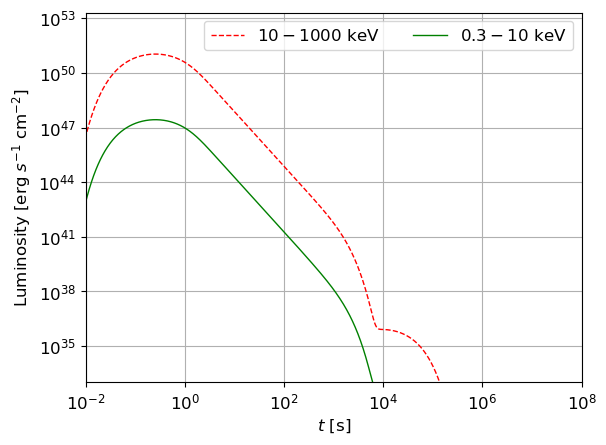

In [17]:
path = '/Users/paris/gemma-v2/gemma-v2/gemma/ejecta/physics/jet'
plot_lc(jet, path=path, model_id=model_id)

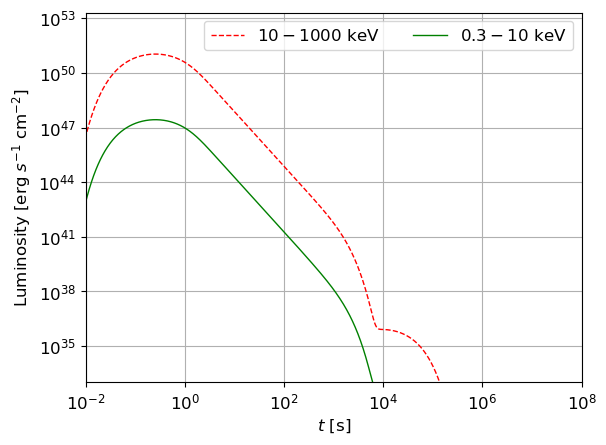

In [13]:
path = '/Users/paris/gemma-v2/gemma-v2/gemma/ejecta/physics/jet'
plot_lc(jet, path=path, model_id=model_id)

In [17]:
test = None
test is not None

False

In [2]:
from scripts.jet import Jet
from scripts.wind_enhanced import Wind
from scripts.magnetar_enhanced import Magnetar
import scripts.helper
import numpy as np
import matplotlib.pyplot as plt
from numpy import int_, newaxis
from scripts.helper import *
from scripts.helper import _int_energy_1d, _interp_1d, band_broadcast
from scripts.const import *
from gemma.ejecta.functions import calculate_ns_compactness, calculate_baryonic_mass
from gemma.ejecta.bns import calculate_bns_disk_mass_kruger

EV_TO_ERG = 1.602176634e-12

class Prompt:
    def __init__(self, components=["jet"],sample_gw_parameters=False, gw_param_mode="chirp_mass", j_struct=None):
        
        self.components = components
        #self.use_extinction = use_extinction
        self.sample_gw_parameters = sample_gw_parameters
        #self.ejecta_function = ejecta_function
        self.gw_param_mode = gw_param_mode

        self.parameter_names = []
        self.parameter_bounds = {}
        component_suffix_map = {"jet": "jet", "wind": "wind"}
        
        self.grid_params = {"n_theta": 500, "n_phi": 100} #default resolution for grid parameters
        self.eta = 1e-4
        self.frac = 0.1
        self.phi_los = np.deg2rad(0) #fixed parameter required for promptx module, connects to total grid along with the input theta (observer line of sight)
        structs = ["tophat", "gaussian", "powerlaw"]
        
        if j_struct is None:
            j_struct = 1
        else:
            if j_struct in structs:
                if j_struct == "tophat":
                    jet_struct=1
                elif j_struct == "gaussian":
                    jet_struct=2
                else:
                    jet_struct=3
            else:
                print("Please pick a valid jet profile, among top-hat, gaussian or power-law")
        self.j_idx = j_struct

        for comp in self.components: #TO BE ADDED: BASE NAMES AND BOUNDS IN ORDER FOR THIS TO WORK
            suffix = component_suffix_map[comp]
            for base_name, bounds in base_params:
                pname = f"{base_name}_{suffix}"
                self.parameter_names.append(pname)
                self.parameter_bounds[pname] = bounds
        
        if "jet" in self.components:
            self.gamma_jet = self.jet_params['gamma_jet']
            self.theta_c = self.jet_params['theta_c']
            self.thera_cut_jet = self.jet_params['theta_cut'] #discuss whether we should fix this
            if sample_gw_parameters:
                self.theta_los = gw_inclination #CORRECT THIS
            else:
                self.theta_los = self.jet_params['theta_los']
            xsi = 0.18 + 0.11/(1+xp.exp(1.5*(mass_ratio-3)))
            self.E_iso_jet = (1-self.frac)*(1-xsi)*calculate_bns_disk_mass_kruger(m2, calculate_ns_compactness(lambda_2, True, systematics_fraction=0.0))*self.eta*c**2/(2*(1-self.theta_c))
            #CHECK E_ISO WITH YVES FOR NUMERICAL COMMENTS

        if "wind" in self.components:
            self.gamma_wind = self.wind_params['gamma_wind']
            self.theta_cut_wind = self.wind_params['theta_cut']
            self.E_iso_wind = self.wind_params['E_iso']
            self.collapse = self.wind_params['collapse'] #boolean
            self.period = self.wind_params['P_0']
            self.mass_remnant = self.wind_params['M']
            self.mag_field = self.wind_params['B_p']
            self.radius = self.wind_params['R']
            self.ellipticity = self.wind_params['eps']
            self.kappa = self.wind_params['kappa']
            self.ejecta_dyn = self.wind_params['m_ejecta_dyn']
            self.vejecta_dyn = self.wind_params['v_ejecta_dyn']

    def generate_jet_lc(self, params, jet_struct):
        self.jet_params = params
        jet_model = Jet(g0=self.gamma_jet, E_iso=self.E_iso, eps0=self.E_iso, n_theta=self.grid_params['n_theta'], n_phi=self.grid_params['n_phi'], theta_c=self.theta_c, theta_cut=self.theta_cut_jet, jet_struct=self.j_idx)
        jet_model.define_structure(g0=self.gamma_jet, eps0=jet_model.eps[0][0], E_iso=self.E_iso, jet_struct=self.j_idx) #CHANGE LORENTZ, EPS, E_ISO ACCORDING TO OUR FORMALISM

        jet_model.create_obs_grid(amati_a=0.41, amati_b=0.83) # Amati relation model of Minaev and Pozanenko 2020
        jet_model.observer(theta_los=self.theta_los, phi_los=self.phi_los)
        


    def generate_wind_lc(self, params):
        self.wind_params = params
        wind = Wind(g0=self.gamma_wind, n_theta=self.grid_params['n_theta'], n_phi=self.grid_params['n_phi'], theta_cut=self.theta_cut_wind)
        wind.observer(theta_los=self.theta_los, phi_los=self.phi_los)
        

    def generate_prompt_xray(self):
        if ("jet" in self.components) and ("wind" in self.components):
            total_L = wind.L_X_tot + jet.L_X_tot
            self.total_X = total_L


╔════════════════════════════════════════════════════════════╗
║        Gemma: GW + EM Multimessenger Analysis Tool         ║
╠════════════════════════════════════════════════════════════╣
║                       Version: 0.0.2                       ║
║                Author: The Gemma Core Team                 ║
║            https://github.com/smelfor/gemma-v2             ║
╚════════════════════════════════════════════════════════════╝



In [1]:
from scripts.jet import Jet

In [2]:
from scripts.jet import Jet
from scripts.wind_enhanced import Wind
from scripts.magnetar_enhanced import Magnetar  # not used yet, but keeping import
import scripts.helper

import numpy as np
from scripts.helper import _int_energy_1d, _interp_1d, band_broadcast
from scripts.const import *  # expects c, etc. in CGS or consistent units

from gemma.ejecta.functions import calculate_ns_compactness
from gemma.ejecta.bns import calculate_bns_disk_mass_kruger
from gemma.utils.units_conversion import*

EV_TO_ERG = 1.602176634e-12


class Prompt:
    """
    PromptX wrapper built in GEMMA style:

    - __init__: configuration + define parameter_names/bounds only
    - update_model(params): called every likelihood evaluation with a new sample
    - generate_light(params): derive E_iso and generate prompt emission outputs
    """

    def __init__(
        self,
        components=("jet",),
        sample_gw_parameters=False,
        gw_param_mode="chirp_mass",
        j_struct=None,
        eta=1e-4,
        frac=0.1,
        phi_los_deg=0.0,
        inclination_key="theta_jn",
        # you can set a fallback if not sampling GW parameters:
        default_theta_los_deg=20.0,
        use_disk_mass_mapping=True
    ):
        self.use_disk_mass_mapping = use_disk_mass_mapping
        self.components = list(components)
        self.sample_gw_parameters = bool(sample_gw_parameters)
        self.gw_param_mode = gw_param_mode

        # Hyperparameters / fixed knobs (you can later promote them to sampled params)
        self.eta = float(eta)
        self.frac = float(frac)
        self.phi_los = np.deg2rad(phi_los_deg)
        self.inclination_key = inclination_key
        self.default_theta_los_deg = float(default_theta_los_deg)

        # Grid parameters
        self.grid_params = {"n_theta": 500, "n_phi": 100}

        # Jet structure index mapping (keep your convention)
        structs = {"tophat": 1, "gaussian": 2, "powerlaw": 3}
        if j_struct is None:
            self.j_idx = 1
        else:
            if isinstance(j_struct, str):
                if j_struct not in structs:
                    raise ValueError("Pick a valid jet profile among: tophat, gaussian, powerlaw")
                self.j_idx = structs[j_struct]
            elif isinstance(j_struct, (int, np.integer)):
                if j_struct not in (1, 2, 3):
                    raise ValueError("j_struct int must be 1 (tophat), 2 (gaussian), or 3 (powerlaw)")
                self.j_idx = int(j_struct)
            else:
                raise TypeError("j_struct must be None, a string ('gaussian'), or an int (1/2/3)")

        # ---- parameters exposed to the sampler ----
        self.parameter_names = []
        self.parameter_bounds = {}

        # Define base params (your original code referenced base_params but didn't define it)
        # This keeps things explicit and closer to how GEMMA does it.
        component_suffix_map = {"jet": "jet", "wind": "wind"}

        # Jet parameters you actually use
        jet_base_params = [
            ("gamma", (10.0, 2000.0)),
            ("theta_c", (0.2, 30.0)),      # degrees
            ("theta_cut", (0.2, 90.0)),    # degrees
        ]

        # Wind parameters you referenced
        wind_base_params = [
            ("gamma", (2.0, 300.0)),
            ("theta_cut", (0.2, 90.0)),    # degrees
            ("E_iso", (1e45, 1e55)),       # if you want to sample wind energy directly
            ("collapse", (0.0, 1.0)),      # treat as continuous; interpret >0.5 as True
            ("P_0", (0.5e-3, 50e-3)),      # seconds (example)
            ("M", (1.0, 3.0)),             # Msun
            ("B_p", (1e13, 1e16)),         # G
            ("R", (8e5, 1.6e6)),           # cm (8-16 km)
            ("eps", (1e-6, 1e-2)),
            ("kappa", (0.1, 20.0)),
            ("m_ejecta_dyn", (1e-4, 0.1)), # Msun
            ("v_ejecta_dyn", (0.05, 0.4)), # c
        ]

        # Add component parameters
        for comp in self.components:
            suffix = component_suffix_map[comp]
            if comp == "jet":
                base_params = jet_base_params
            elif comp == "wind":
                base_params = wind_base_params
            else:
                raise ValueError(f"Unknown component '{comp}', expected 'jet' and/or 'wind'")

            for base_name, bounds in base_params:
                pname = f"{base_name}_{suffix}"
                self.parameter_names.append(pname)
                self.parameter_bounds[pname] = bounds

        # If not sampling GW parameters, we must sample or set theta_los
        if not self.sample_gw_parameters:
            self.parameter_names.append("theta_los")
            self.parameter_bounds["theta_los"] = (0.0, 90.0)
        else:
            # When sampling GW params, we expect inclination to be in the global parameter dict
            # (we add it here so this wrapper can work standalone too).
            self.parameter_names.append(self.inclination_key)
            self.parameter_bounds[self.inclination_key] = (0.0, np.pi)

            # Minimal GW/EOS inputs needed for your E_iso mapping
            # (You can delete these if they come from the global sampler anyway.)
            if self.gw_param_mode == "mass":
                for name, bounds in [
                    ("mass_1", (0.8, 3.0)),
                    ("mass_2", (0.8, 3.0)),
                    ("lambda_2", (0.0, 5000.0)),
                ]:
                    self.parameter_names.append(name)
                    self.parameter_bounds[name] = bounds
            elif self.gw_param_mode == "chirp_mass":
                # NOTE: requires conversion chirp_mass+mass_ratio -> m1,m2 implemented in _extract_masses()
                for name, bounds in [
                    ("chirp_mass", (0.8, 2.0)),
                    ("mass_ratio", (0.05, 1.0)),  # q=m2/m1
                    ("lambda_2", (0.0, 5000.0)),  # simplest; or lambda_tilde if you prefer
                ]:
                    self.parameter_names.append(name)
                    self.parameter_bounds[name] = bounds
            else:
                raise ValueError("gw_param_mode must be 'mass' or 'chirp_mass'")

        # Cached state
        self.params = None
        self.jet_model = None
        self.wind_model = None
        self.total_X = None

        # Add manual jet energy if we are NOT using the ejecta/disk-mass mapping
        if ("jet" in self.components) and (not self.use_disk_mass_mapping):
            self.parameter_names.append("E_iso_jet")
            self.parameter_bounds["E_iso_jet"] = (1e45, 1e55)  # adjust prior if needed


    # -----------------------
    # Public API for sampler
    # -----------------------
    def bounds_check(self, params):
        for name in self.parameter_names:
            if name not in params:
                continue
            lo, hi = self.parameter_bounds[name]
            v = float(params[name])
            if not (lo <= v <= hi):
                raise ValueError(f"[Bound check failed] {name}={v} not in [{lo},{hi}]")

    def update_model(self, params, check_bounds=False, dry_run=True):
        print('Updating model...')
        if check_bounds:
            print('Checking bounds...')
            self.bounds_check(params)
            print('Bounds checked!')
        self.params = params
        if dry_run:
            # only compute derived quantities; no PromptX calls
            print('Starting dry run...')
            theta_los = self._get_theta_los(params)
            print('thetalos ok!')
            theta_c = np.deg2rad(float(params["theta_c_jet"]))
            print('core ok!')
            E_iso_jet = self._derive_Eiso_jet(params, theta_c)
            return {"theta_los": theta_los, "E_iso_jet": E_iso_jet}
        self.generate_light(params)

    # -----------------------
    # Core model evaluation
    # -----------------------
    def generate_light(self, params):
        """
        For this sample:
        - derive jet energetics (E_iso_jet) from disk mass mapping
        - run PromptX jet/wind models
        - cache total_X (and keep jet_model/wind_model for later extraction)
        """
        # Viewing angle
        theta_los = self._get_theta_los(params)

        # Jet
        jet_L = None
        if "jet" in self.components:
            jet_L = self.generate_jet_lc(params, theta_los)

        # Wind
        wind_L = None
        if "wind" in self.components:
            wind_L = self.generate_wind_lc(params, theta_los)

        # Combine
        if (jet_L is not None) and (wind_L is not None):
            # Make sure they are on same time grid:
            x_jet = jet_L.L_X_tot
            x_wind = wind_L.L_X_tot
            # Lw = np.interp(t, wind_L["t"], wind_L["Lx"], left=0.0, right=0.0)
            # self.total_X = {"t": t, "Lx": jet_L["Lx"] + Lw}
            self.total_X = x_jet + x_wind
            self.t = jet_L.t
        elif jet_L is not None:
            self.total_X = jet_L.L_X_tot
            self.t = jet_L.t
        elif wind_L is not None:
            self.total_X = wind_L.L_X_tot
            self.t = wind_L.engine.t
        else:
            raise RuntimeError("No components enabled")

    def generate_jet_lc(self, params, theta_los_rad):
        """
        Build and run PromptX Jet model for current params.
        Returns dict with time grid and X-ray luminosity/flux-like quantity.
        """
        # Parse jet params (degrees -> radians where needed)
        gamma_jet = float(params["gamma_jet"])
        theta_c = np.deg2rad(float(params["theta_c_jet"]))
        theta_cut = np.deg2rad(float(params["theta_cut_jet"]))
        print('Proceeding with isojet...')
        # Derive E_iso_jet from your mapping
        E_iso_jet = self._derive_Eiso_jet(params, theta_c)

        # PromptX uses eps0 in some places; common mapping is eps0 = E_iso/(4π)
        eps0 = E_iso_jet
        #eps0 = E_iso_jet / (4.0 * np.pi)

        jet_model = Jet(
            g0=gamma_jet,
            E_iso=E_iso_jet,
            eps0=eps0,
            n_theta=self.grid_params["n_theta"],
            n_phi=self.grid_params["n_phi"],
            theta_c=theta_c,
            theta_cut=theta_cut,
            jet_struct=self.j_idx,
        )
        print('Model Constructed...')

        # Ensure structure is consistent with E_iso/eps0 choice
        jet_model.define_structure(
            g0=gamma_jet,
            eps0=eps0,
            E_iso=E_iso_jet,
            jet_struct=self.j_idx,
        )

        jet_model.create_obs_grid(amati_a=0.41, amati_b=0.83)
        jet_model.observer(theta_los=float(theta_los_rad), phi_los=float(self.phi_los))
        print('Structure Constructed...')

        self.jet_model = jet_model

        return jet_model

        # t, Lx = self._extract_xray_lc(jet_model)
        # return {"t": t, "Lx": Lx}

    def generate_wind_lc(self, params, theta_los_rad):
        """
        Build and run PromptX Wind model for current params.
        Returns dict with time grid and X-ray luminosity/flux-like quantity.
        """
        gamma_wind = float(params["gamma_wind"])
        theta_cut = np.deg2rad(float(params["theta_cut_wind"]))

        wind = Wind(
            g0=gamma_wind,
            n_theta=self.grid_params["n_theta"],
            n_phi=self.grid_params["n_phi"],
            theta_cut=theta_cut,
        )
        wind.observer(theta_los=float(theta_los_rad), phi_los=float(self.phi_los))

        # If Wind needs extra init (E_iso, collapse, magnetar params) do it here.
        # Your original script stored them, so keep them available:
        wind.E_iso = float(params["E_iso_wind"])
        wind.collapse = bool(float(params["collapse_wind"]) > 0.5)

        self.wind_model = wind

        return wind

    # -----------------------
    # Helpers
    # -----------------------
    def _get_theta_los(self, params):
        if self.sample_gw_parameters:
            if self.inclination_key not in params:
                raise KeyError(f"Missing GW inclination key '{self.inclination_key}' in params")
            return float(params[self.inclination_key])  # already radians
        # otherwise sample or use default
        if "theta_los" in params:
            return np.deg2rad(float(params["theta_los"]))
        return np.deg2rad(self.default_theta_los_deg)

    def _extract_masses(self, params):
        """
        Returns (m1, m2) in Msun.
        Supports gw_param_mode 'mass' directly.
        For 'chirp_mass', you MUST plug in bilby conversion (or provide mass_1/mass_2 globally).
        """
        if "mass_1" in params and "mass_2" in params:
            return float(params["mass_1"]), float(params["mass_2"])

        if self.gw_param_mode == "mass":
            raise KeyError("gw_param_mode='mass' requires mass_1 and mass_2 in params")

        if self.gw_param_mode == "chirp_mass":
            # If you already have bilby conversion available in your environment,
            # you should import it and do the proper conversion here.
            # Example:
            # from gemma.utils import bilby_conversion as bilby_conv
            # m1, m2 = bilby_conv.chirp_mass_and_mass_ratio_to_component_masses(params["chirp_mass"], params["mass_ratio"])
            raise ValueError(
                "gw_param_mode='chirp_mass' requires chirp_mass+mass_ratio conversion. "
                "Either provide mass_1/mass_2 directly in params, or implement bilby conversion here."
            )

        raise ValueError(f"Unknown gw_param_mode: {self.gw_param_mode}")

    def _derive_Eiso_jet(self, params, theta_c_rad):
        """
        Your intent: compute disk mass from Kruger fit, apply efficiency, then convert to E_iso.

        This version:
          E_k = (1-frac)*(1-xi)*M_disk*eta*c^2
          E_iso ≈ 2 E_k / theta_c^2   (small-angle Gaussian/powerlaw normalization)
        """
        # Need mass_1/mass_2 and lambda_2 at minimum
        if not self.use_disk_mass_mapping:
            if "E_iso_jet" not in params:
                raise KeyError("use_disk_mass_mapping=False but E_iso_jet not provided")
            return float(params["E_iso_jet"])

        m1, m2 = self._extract_masses(params)
        if "lambda_2" not in params:
            raise KeyError("lambda_2 missing: needed for compactness -> disk mass -> E_iso_jet")
        lambda_2 = float(params["lambda_2"])

        # Compactness and disk mass (Kruger)
        C2 = float(calculate_ns_compactness(lambda_2, True, systematics_fraction=0.0))
        print('Compactness Calculated...')
        m_disk = float(calculate_bns_disk_mass_kruger(m2, C2))  # assumed Msun

        # Your xi(q) expression (q interpreted as m1/m2)
        q = max(1e-6, m1 / m2)
        xi = 0.18 + 0.11 / (1.0 + np.exp(1.5 * (q - 3.0)))

        # Energy budget (units depend on scripts.const; assume c in cm/s and M_disk in Msun)
        # Convert Msun -> grams if cgs constants expect that:
        E_k = (1.0 - self.frac) * (1.0 - xi) * (m_disk*M_sun_cgs) * self.eta * (c_cgs ** 2)

        # Map to E_iso
        denom = max(1e-12, 1.0 - np.cos(theta_c_rad))
        E_iso = 2.0 * E_k / denom
        return float(E_iso)

    @staticmethod
    def _extract_xray_lc(obj):
        """
        Try to extract (t, Lx) arrays from PromptX Jet/Wind objects.
        Adjust attribute names here once you confirm PromptX outputs.

        Returns numpy arrays.
        """
        t = None
        for k in ("t", "t_obs", "t_grid", "_t"):
            if hasattr(obj, k):
                t = getattr(obj, k)
                break

        Lx = None
        for k in ("L_X_tot", "Lx", "lx", "F_X_tot", "Fx"):
            if hasattr(obj, k):
                Lx = getattr(obj, k)
                break

        if t is None or Lx is None:
            # Help you debug quickly
            candidates = [k for k in dir(obj) if ("X" in k or "t" in k or "lc" in k or "flux" in k or "lum" in k)]
            raise AttributeError(
                f"Could not extract X-ray lightcurve from {type(obj)}. "
                f"Candidate attributes: {candidates}"
            )

        return np.asarray(t, dtype=float), np.asarray(Lx, dtype=float)

    def check_print(self):
        print('Object OK!')


╔════════════════════════════════════════════════════════════╗
║        Gemma: GW + EM Multimessenger Analysis Tool         ║
╠════════════════════════════════════════════════════════════╣
║                       Version: 0.0.2                       ║
║                Author: The Gemma Core Team                 ║
║            https://github.com/smelfor/gemma-v2             ║
╚════════════════════════════════════════════════════════════╝



In [2]:
import numpy as np
import matplotlib.pyplot as plt


# 1) Instantiate the model with wind only
prompt = Prompt(
    components=("wind",),
    sample_gw_parameters=False,   # we will provide theta_los in degrees
    gw_param_mode="mass",         # irrelevant for wind-only unless your Wind uses masses
    j_struct="gaussian",          # irrelevant for wind-only, but fine
)

# 2) Build one parameter dictionary
# Must include:
#   - theta_los (deg) because sample_gw_parameters=False
#   - wind params with "_wind" suffix as defined in your parameter_names
params = {
    # viewing angle (degrees)
    "theta_los": 20.0,

    # wind component parameters
    "gamma_wind": 30.0,
    "theta_cut_wind": 45.0,       # degrees
    "E_iso_wind": 1e48,           # erg (or whatever Wind expects)
    "collapse_wind": 0.0,         # 0/1 (interpreted as False/True)

    # the rest are in your wind_base_params list; only needed if Wind actually uses them
    # (safe to include; Wind may ignore them)
    "P_0_wind": 0.01,             # s
    "M_wind": 2.2,                # Msun
    "B_p_wind": 1e15,             # G
    "R_wind": 1.2e6,              # cm
    "eps_wind": 1e-4,
    "kappa_wind": 1.0,
    "m_ejecta_dyn_wind": 1e-3,    # Msun
    "v_ejecta_dyn_wind": 0.2
}

In [3]:
prompt.update_model(params, check_bounds=False, dry_run=False)

Updating model...
Normalized L0: 1.079097244454538e+52


In [4]:
prompt.parameter_names

['gamma_wind',
 'theta_cut_wind',
 'E_iso_wind',
 'collapse_wind',
 'P_0_wind',
 'M_wind',
 'B_p_wind',
 'R_wind',
 'eps_wind',
 'kappa_wind',
 'm_ejecta_dyn_wind',
 'v_ejecta_dyn_wind',
 'E_iso_jet',
 'theta_los']

In [2]:
prompt = Prompt(
    components=("jet",),
    sample_gw_parameters=False,
    gw_param_mode="mass",              # irrelevant in manual mode
    j_struct="tophat",
    use_disk_mass_mapping=False,       # <-- critical
)

params = {
    "gamma_jet": 200.0,
    "theta_c_jet": 5.0,        # degrees
    "theta_cut_jet": 30.0,     # degrees
    "theta_los": 20.0,         # degrees
    "E_iso_jet": 1e51,         # erg (manual)
}

prompt.update_model(params, check_bounds=True, dry_run=False)

# t = prompt.total_X["t"]
# Lx = prompt.total_X["Lx"]

# print("jet ok:", len(t), len(Lx))
# plt.figure()
# plt.loglog(t, Lx)
# plt.xlabel("time")
# plt.ylabel("Lx (model units)")
# plt.title("Jet-only manual E_iso test")
# plt.show()


Updating model...
Checking bounds...
Bounds checked!
Proceeding with isojet...
Model Constructed...
Spectrum integral: 2.294283038211402e+47
Light curve integral (gamma): 5.363411852166161e+47
Light curve integral (X): 1.096608030899251e+44
E_peak: 870843.1497690724 eV
Structure Constructed...


In [1]:
import os
os.environ["NUMBA_DISABLE_JIT"] = "1"
os.environ["NUMBA_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
print("Pinned threads + disabled numba JIT")

Pinned threads + disabled numba JIT


In [2]:
import sys, faulthandler
faulthandler.enable()

def p(x):
    print(x); sys.stdout.flush()

from gemma.ejecta.functions import calculate_ns_compactness
from gemma.ejecta.bns import calculate_bns_disk_mass_kruger

p("A: start")
p("B: compactness")
C2 = calculate_ns_compactness(300.0, True, systematics_fraction=0.0)
p(f"C: got C2={C2}")

p("D: disk mass")
md = calculate_bns_disk_mass_kruger(1.2, float(C2))
p(f"E: got m_disk={md}")


╔════════════════════════════════════════════════════════════╗
║        Gemma: GW + EM Multimessenger Analysis Tool         ║
╠════════════════════════════════════════════════════════════╣
║                       Version: 0.0.2                       ║
║                Author: The Gemma Core Team                 ║
║            https://github.com/smelfor/gemma-v2             ║
╚════════════════════════════════════════════════════════════╝

A: start
B: compactness
C: got C2=0.18045158198503253
D: disk mass
E: got m_disk=0.0006443491828022103


In [3]:
prompt = Prompt(
    components=("jet",),            # just jet for now
    sample_gw_parameters=False,     # we will pass theta_los
    gw_param_mode="mass",           # so _extract_masses expects mass_1/mass_2
    j_struct="tophat",            # or 1/2/3
    eta=1e-4,
    frac=0.1,
    phi_los_deg=0.0,
    default_theta_los_deg=20.0,
)

In [4]:
prompt.check_print()

Object OK!


In [5]:
params = {
    # jet knobs
    "gamma_jet": 300.0,
    "theta_c_jet": 5.0,        # degrees
    "theta_cut_jet": 30.0,     # degrees

    # viewing angle
    "theta_los": 20.0,         # degrees

    # binary / EOS inputs used in _derive_Eiso_jet
    "mass_1": 1.4,             # Msun
    "mass_2": 1.2,             # Msun
    "lambda_2": 300.0,         # dimensionless tidal deformability
}

In [6]:
import sys
print("CELL START")
sys.stdout.flush()

out = prompt.update_model(params)

print("CELL END", out)
sys.stdout.flush()

CELL START
Updating model...
Starting dry run...
thetalos ok!
core ok!
Compactness Calculated...
CELL END {'theta_los': np.float64(0.3490658503988659), 'E_iso_jet': 3.9033236668961133e+49}


In [9]:
prompt.t

AttributeError: 'Prompt' object has no attribute 't'

In [7]:
prompt.total_X

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Import your wrapper (adjust module path)

# 1) Create model instance
prompt = Prompt(
    components=("jet",),            # just jet for now
    sample_gw_parameters=False,     # we will pass theta_los
    gw_param_mode="chirp_mass",           # so _extract_masses expects mass_1/mass_2
    j_struct="tophat",            # or 1/2/3
    eta=1e-4,
    frac=0.1,
    phi_los_deg=0.0,
    default_theta_los_deg=20.0,
)

# 2) Build one parameter dictionary (ONE "sample")
# Must include:
#   - jet parameters: gamma_jet, theta_c_jet, theta_cut_jet
#   - theta_los (deg) since sample_gw_parameters=False
#   - mass_1, mass_2, lambda_2 because _derive_Eiso_jet uses them
params = {
    # jet knobs
    "gamma_jet": 300.0,
    "theta_c_jet": 5.0,        # degrees
    "theta_cut_jet": 30.0,     # degrees

    # viewing angle
    "theta_los": 20.0,         # degrees

    # binary / EOS inputs used in _derive_Eiso_jet
    "mass_1": 1.4,             # Msun
    "mass_2": 1.2,             # Msun
    "lambda_2": 300.0,         # dimensionless tidal deformability
}

# 3) Run one evaluation
prompt.update_model(params, check_bounds=True)

# # 4) Access outputs
# # Your wrapper caches a dict with keys "t" and "Lx" in prompt.total_X
# t = prompt.total_X["t"]
# Lx = prompt.total_X["Lx"]

# print("Computed lightcurve:")
# print("  t[0:5] =", t[:5])
# print("  Lx[0:5] =", Lx[:5])

# # 5) Plot (optional)
# plt.figure()
# plt.loglog(t, Lx)
# plt.xlabel("time")
# plt.ylabel("Lx (model units)")
# plt.title("PromptX jet prediction (single evaluation)")
# plt.show()


In [ ]:
# promptx_wrapper.py

from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple, Union

import numpy as np

# GEMMA backend (keeps you compatible with numpy/jax/cupy where possible)
from gemma.backend import get_arraylib
xp = get_arraylib()

from gemma.ejecta.functions import calculate_ns_compactness
from gemma.ejecta.bns import calculate_bns_disk_mass_kruger

# Units/constants (use GEMMA's if you have them; otherwise keep your existing scripts.const)
from gemma.utils.units_conversion import c_cgs, M_sun_cgs, Mpc_in_cm

# PromptX objects (adjust imports to your local PromptX install layout)
from scripts.jet import Jet
# from scripts.wind import Wind  # uncomment if you have it


@dataclass(frozen=True)
class GridParams:
    n_theta: int = 500
    n_phi: int = 100


class Prompt:
    """
    PromptX wrapper in GEMMA style:
      - __init__: declare parameters + fixed configuration
      - update_model(params): called every likelihood evaluation / sampling step
      - generate_light(params): runs PromptX and caches outputs
    """

    def __init__(
        self,
        components: List[str] = ["jet"],
        sample_gw_parameters: bool = False,
        gw_param_mode: str = "chirp_mass",
        jet_profile: str = "gaussian",          # "tophat" | "gaussian" | "powerlaw"
        eta: float = 1e-4,                      # accretion-to-jet efficiency (fixed hyperparameter)
        frac_wind: float = 0.1,                 # fraction of disk energy not going to jet (fixed hyperparameter)
        phi_los_deg: float = 0.0,               # PromptX requires this; you fixed it, keep fixed
        inclination_key: str = "theta_jn",      # GW inclination parameter name (bilby often uses theta_jn)
    ):
        self.components = components
        self.sample_gw_parameters = sample_gw_parameters
        self.gw_param_mode = gw_param_mode

        self.eta = float(eta)
        self.frac_wind = float(frac_wind)
        self.grid = GridParams()
        self.phi_los = np.deg2rad(phi_los_deg)
        self.inclination_key = inclination_key

        # Map profile string -> PromptX jet_struct index (based on your draft)
        profiles = {"tophat": 1, "gaussian": 2, "powerlaw": 3}
        if jet_profile not in profiles:
            raise ValueError(f"jet_profile must be one of {list(profiles.keys())}, got {jet_profile}")
        self.jet_profile = jet_profile
        self.j_idx = profiles[jet_profile]

        # --- parameters exposed to bilby ---
        # Keep this minimal and explicit; do NOT compute derived stuff in __init__.
        self.parameter_names: List[str] = []
        self.parameter_bounds: Dict[str, Tuple[float, float]] = {}

        # Prompt-specific parameters (jet)
        if "jet" in self.components:
            jet_params = [
                ("gamma_jet", (10.0, 2000.0)),
                ("theta_c_jet", (0.2, 30.0)),      # degrees
                ("theta_cut_jet", (0.2, 90.0)),    # degrees
            ]
            # If you are NOT taking theta_los from GW inclination, you must sample it
            if not self.sample_gw_parameters:
                jet_params.append(("theta_los_deg", (0.0, 90.0)))

            for name, bounds in jet_params:
                self.parameter_names.append(name)
                self.parameter_bounds[name] = bounds

        # Prompt-specific parameters (wind) — placeholder if you add it later
        # if "wind" in self.components:
        #     wind_params = [
        #         ("gamma_wind", (2.0, 300.0)),
        #         ("theta_cut_wind", (0.2, 90.0)),
        #         ("E_iso_wind", (1e45, 1e55)),
        #     ]
        #     for name, bounds in wind_params:
        #         self.parameter_names.append(name)
        #         self.parameter_bounds[name] = bounds

        # Shared parameters needed to turn luminosity into observed flux etc.
        # (you likely already sample these in your KN/GW pipeline; include here so
        #  this wrapper can be evaluated standalone too)
        for name, bounds in [
            ("luminosity_distance", (0.1, 5000.0)),  # Mpc
        ]:
            self.parameter_names.append(name)
            self.parameter_bounds[name] = bounds

        # If you want this wrapper to compute E_iso from BNS disk mass, it needs GW/EOS info.
        # Minimal set for your current formula path:
        #   - masses (or chirp_mass+mass_ratio) and lambda_2 or lambda_tilde.
        # I’m including a common set; adjust to match your joint sampler priors.
        if self.sample_gw_parameters:
            if self.gw_param_mode == "chirp_mass":
                for name, bounds in [
                    ("chirp_mass", (0.8, 2.0)),
                    ("mass_ratio", (0.05, 1.0)),      # bilby convention often q=m2/m1 <= 1
                    ("lambda_tilde", (0.0, 5000.0)),
                    (self.inclination_key, (0.0, np.pi)),  # radians
                ]:
                    self.parameter_names.append(name)
                    self.parameter_bounds[name] = bounds
            elif self.gw_param_mode == "mass":
                for name, bounds in [
                    ("mass_1", (0.8, 3.0)),
                    ("mass_2", (0.8, 3.0)),
                    ("lambda_2", (0.0, 5000.0)),
                    (self.inclination_key, (0.0, np.pi)),  # radians
                ]:
                    self.parameter_names.append(name)
                    self.parameter_bounds[name] = bounds
            else:
                raise ValueError("gw_param_mode must be 'chirp_mass' or 'mass'")

        # Internal cache for latest evaluation
        self.params: Optional[Dict[str, float]] = None
        self._cache: Dict[str, object] = {}

    # --------- optional: bounds check like EMbase ----------
    def bounds_check(self, param_dict: Dict[str, float]) -> None:
        for name in self.parameter_names:
            if name not in param_dict:
                continue
            low, high = self.parameter_bounds[name]
            val = float(param_dict[name])
            if not (low <= val <= high):
                raise ValueError(f"[Bound check failed] '{name}'={val:.4g} outside [{low:.4g},{high:.4g}]")

    # --------- key GEMMA-like entry point ----------
    def update_model(self, params: Dict[str, float], check_bounds: bool = False) -> None:
        """
        Called every likelihood evaluation with a fresh sample `params`.
        """
        if check_bounds:
            self.bounds_check(params)

        self.params = params
        self.generate_light(params)

    # --------- your forward model ----------
    def generate_light(self, params: Dict[str, float]) -> None:
        """
        Run PromptX for the current sample; cache lightcurve arrays for likelihood use.
        """
        # ---- viewing geometry ----
        if self.sample_gw_parameters:
            theta_los = float(params[self.inclination_key])  # radians
        else:
            theta_los = np.deg2rad(float(params["theta_los_deg"]))

        # ---- distance (used if PromptX gives luminosity and you want flux) ----
        D_cm = float(params["luminosity_distance"]) * Mpc_in_cm

        out = {}

        # ---- JET component ----
        if "jet" in self.components:
            gamma_jet = float(params["gamma_jet"])
            theta_c = np.deg2rad(float(params["theta_c_jet"]))
            theta_cut = np.deg2rad(float(params["theta_cut_jet"]))

            # --- derive E_iso from your disk-mass-based energy budget ---
            # This follows your intent: sample GW/ejecta-ish variables, not E_iso directly.
            E_iso = self._derive_Eiso_jet(params, theta_c, theta_cut)

            jet_model = Jet(
                g0=gamma_jet,
                E_iso=E_iso,
                eps0=self._eps0_from_Eiso(E_iso),
                n_theta=self.grid.n_theta,
                n_phi=self.grid.n_phi,
                theta_c=theta_c,
                theta_cut=theta_cut,
                jet_struct=self.j_idx,
            )

            # Your draft called define_structure again; keep it, but pass self-consistent values
            jet_model.define_structure(
                g0=gamma_jet,
                eps0=self._eps0_from_Eiso(E_iso),
                E_iso=E_iso,
                jet_struct=self.j_idx,
            )

            # PromptX grid & observer
            jet_model.create_obs_grid(amati_a=0.41, amati_b=0.83)
            jet_model.observer(theta_los=theta_los, phi_los=self.phi_los)

            # Pull out a usable LC from PromptX (robust to attribute naming)
            t_jet, y_jet = self._get_promptx_lc(jet_model)

            out["jet"] = {"t": t_jet, "y": y_jet, "D_cm": D_cm}

        # ---- WIND component (optional / TODO) ----
        # if "wind" in self.components:
        #     ...

        # ---- combine if both exist (your original intent) ----
        if "jet" in out and "wind" in out:
            # You must ensure time grids match; simplest is to interpolate wind onto jet times
            t = out["jet"]["t"]
            y_w = np.interp(t, out["wind"]["t"], out["wind"]["y"], left=0.0, right=0.0)
            y = out["jet"]["y"] + y_w
            out["total"] = {"t": t, "y": y, "D_cm": out["jet"]["D_cm"]}
        elif "jet" in out:
            out["total"] = out["jet"]
        elif "wind" in out:
            out["total"] = out["wind"]
        else:
            raise RuntimeError("No components enabled. components must contain 'jet' and/or 'wind'.")

        self._cache = out

    # ---------- helper: derive E_iso ----------
    def _derive_Eiso_jet(self, params: Dict[str, float], theta_c: float, theta_cut: float) -> float:
        """
        Implements your energy mapping:
          E_k ~ (1-frac)*(1-xi)*M_disk*eta*c^2
        then converts to an on-axis isotropic-equivalent E_iso using a profile-dependent mapping.
        """
        # --- get m2 and lambda2 (depending on gw_param_mode) ---
        if self.sample_gw_parameters and self.gw_param_mode == "chirp_mass":
            # We avoid depending on bilby conversion utilities here; you can plug those in if desired.
            # If you already have m1/m2 in your global parameter dict, prefer that instead.
            raise ValueError(
                "gw_param_mode='chirp_mass' needs a chirp_mass+mass_ratio -> (m1,m2) conversion. "
                "Either switch gw_param_mode='mass' for this wrapper, "
                "or plug in bilby conversions here."
            )

        # mass mode
        if "mass_2" in params:
            m2 = float(params["mass_2"])
        else:
            raise KeyError("mass_2 missing: needed to compute disk mass and E_iso_jet")

        # lambda_2 (direct) OR compute it upstream and inject into params
        if "lambda_2" in params:
            lambda_2 = float(params["lambda_2"])
        else:
            raise KeyError("lambda_2 missing: needed to compute compactness and E_iso_jet")

        # --- compactness & disk mass ---
        C2 = float(calculate_ns_compactness(lambda_2, True, systematics_fraction=0.0))
        m_disk_msun = float(calculate_bns_disk_mass_kruger(m2, C2))  # assumed Msun output

        # --- your xi(q) factor ---
        # Your draft used something like mass_ratio-3; that only makes sense if q=m1/m2 >= 1.
        # If you have mass_1/mass_2 available, use it; otherwise set q=1 as a safe fallback.
        if "mass_1" in params:
            q = float(params["mass_1"]) / float(params["mass_2"])
        else:
            q = 1.0

        xi = 0.18 + 0.11 / (1.0 + np.exp(1.5 * (q - 3.0)))

        # --- energy budget ---
        E_k = (1.0 - self.frac_wind) * (1.0 - xi) * (m_disk_msun * M_sun_cgs) * self.eta * (c_cgs ** 2)

        # --- convert to on-axis E_iso depending on jet profile ---
        if self.jet_profile == "tophat":
            # true energy E_k = (E_iso/2)*(1-cos(theta))  =>  E_iso = 2E_k/(1-cos(theta))
            theta0 = float(theta_c)  # treat theta_c as top-hat half-opening
            denom = max(1e-12, 1.0 - np.cos(theta0))
            E_iso = 2.0 * E_k / denom
        else:
            # gaussian/powerlaw: small-angle approx normalization commonly used
            denom = max(1e-12, theta_c ** 2)
            E_iso = 2.0 * E_k / denom

        return float(E_iso)

    @staticmethod
    def _eps0_from_Eiso(E_iso: float) -> float:
        """
        PromptX sometimes uses eps0 as energy per sr, while E_iso is isotropic-equivalent.
        A safe/default mapping is eps0 = E_iso / (4π).
        If your local PromptX expects something different, change it here *only*.
        """
        #return float(E_iso) / (4.0 * np.pi)
        return float(E_iso)

    # ---------- helper: extract LC from PromptX object ----------
    @staticmethod
    def _get_promptx_lc(obj) -> Tuple[np.ndarray, np.ndarray]:
        """
        Tries common PromptX attribute conventions.
        Returns (t, y), both numpy arrays.
        """
        # Try time arrays
        t_candidates = ["t", "t_obs", "t_grid", "t_lc"]
        y_candidates = ["L_X_tot", "F_X_tot", "lc", "lightcurve", "flux", "luminosity"]

        t = None
        for k in t_candidates:
            if hasattr(obj, k):
                t = getattr(obj, k)
                break

        y = None
        for k in y_candidates:
            if hasattr(obj, k):
                y = getattr(obj, k)
                break

        if t is None or y is None:
            keys = [k for k in dir(obj) if ("X" in k or "lc" in k or "t" in k or "flux" in k or "lum" in k)]
            raise AttributeError(
                "Could not extract (t, y) lightcurve from PromptX object. "
                f"Found candidate attributes: {keys}"
            )

        return np.asarray(t, dtype=float), np.asarray(y, dtype=float)

    # ---------- convenience accessors for likelihood layer ----------
    def get_total_lc(self) -> Tuple[np.ndarray, np.ndarray]:
        """
        Returns last computed total lightcurve (t, y) from cache.
        """
        if not self._cache:
            raise RuntimeError("Model not evaluated yet. Call update_model(params) first.")
        return self._cache["total"]["t"], self._cache["total"]["y"]


In [21]:
test = ['jet']
'jet' and 'wind' in test

False